In [1]:
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "600"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("HF_ENDPOINT:", os.environ.get("HF_ENDPOINT"))
print("HF_HUB_DISABLE_XET:", os.environ.get("HF_HUB_DISABLE_XET"))

HF_ENDPOINT: https://hf-mirror.com
HF_HUB_DISABLE_XET: 1


In [14]:
MODEL_NAME   = "microsoft/deberta-v3-large"
DATA_DIR     = "/home/yangdejin/nlpcc/nlpcc_task2/data"
OUTPUT_DIR   = "/home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/deberta_v3_large"
BATCH_SIZE   = 16
MAX_LENGTH   = 512
LR           = 5e-5
NUM_EPOCHS   = 5
LORA_R       = 16
LORA_ALPHA   = 32
SEED         = 3407
os.makedirs(OUTPUT_DIR, exist_ok=True)
TRAIN_CONTEXT_MODE = "full_context"
EVAL_CONTEXT_MODE = "response_only"

In [3]:
import json
import os
from collections import Counter

VALUE_LABELS = [
    "Self-direction\u2013thought",
    "Self-direction\u2013action",
    "Stimulation",
    "Hedonism",
    "Achievement",
    "Power\u2013dominance",
    "Power\u2013resources",
    "Face",
    "Security\u2013personal",
    "Security\u2013societal",
    "Tradition",
    "Conformity\u2013rules",
    "Conformity\u2013interpersonal",
    "Humility",
    "Benevolence\u2013dependability",
    "Benevolence\u2013caring",
    "Universalism\u2013concern",
    "Universalism\u2013nature",
    "Universalism\u2013tolerance",
]
NUM_CLASSES = len(VALUE_LABELS)
label2id = {v:i for i, v in enumerate(VALUE_LABELS)}
id2label = {i:v for i, v in enumerate(VALUE_LABELS)}
print(f"num of classes:{NUM_CLASSES}")

train_vals = []
with open(os.path.join(DATA_DIR, "train.jsonl")) as f:
  for line in f:
    train_vals.append(json.loads(line)["Value"])

counter = Counter(train_vals)
print("Train class distribution:\n")
for label in VALUE_LABELS:
  print(f"{label} : {counter[label]}")

num of classes:19
Train class distribution:

Self-direction–thought : 119
Self-direction–action : 124
Stimulation : 400
Hedonism : 164
Achievement : 174
Power–dominance : 156
Power–resources : 237
Face : 258
Security–personal : 202
Security–societal : 70
Tradition : 90
Conformity–rules : 385
Conformity–interpersonal : 236
Humility : 100
Benevolence–dependability : 189
Benevolence–caring : 317
Universalism–concern : 160
Universalism–nature : 71
Universalism–tolerance : 68


In [4]:
# Cell 4: 数据加载 + 文本拼接
import json
import torch
import numpy as np
from datasets import Dataset

def build_text(row, context_mode="full_context"):
    response = str(row.get("Consistent Value Response", "")).strip()
    if context_mode == "response_only":
        return "Response: " + response
    if context_mode == "full_context":
        parts = []
        if row.get("Scenario"):
            parts.append("Senario: " + row.get("Senario").strip())
        if row.get("Question"):
            parts.append("Question: " + row.get("Question").strip())
        if response:
            parts.append("Response: " + response)
        return " [SEP] ".join(parts)
    
def load_jsonl(path, has_label=True, context_mode = "full_context"):

    texts, labels = [], []
    with open(path) as f:
        for line in f:
            row = json.loads(line)
            texts.append(build_text(row, context_mode))
            if has_label:
                labels.append(label2id[row["Value"]])
    if has_label:
        return Dataset.from_dict({"text": texts, "label": labels})
    return Dataset.from_dict({"text": texts})

train_dataset = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"), context_mode=EVAL_CONTEXT_MODE)
dev_dataset   = load_jsonl(os.path.join(DATA_DIR, "dev.jsonl"), context_mode=EVAL_CONTEXT_MODE)

print(f"Train size : {len(train_dataset)}")
print(f"Dev size   : {len(dev_dataset)}")
print(f"\nTrain sample text:\n{train_dataset[0]['text'][:300]}")
print(f"\nDev sample text:\n{dev_dataset[0]['text'][:300]}")

Train size : 3520
Dev size   : 514

Train sample text:
Response: I would suggest alternative solutions diplomatically, ensuring my input is heard without challenging the manager openly, prioritizing team harmony and respect for hierarchy.

Dev sample text:
Response: I would prioritize maintaining that frequent contact despite my schedule, as I want to ensure my teammate feels valued, included, and that our teamwork remains perfectly smooth.


In [5]:
# Cell 5: 加载模型 + Tokenizer
import torch
from unsloth import FastModel
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding

model, tokenizer = FastModel.from_pretrained(
    model_name=MODEL_NAME,
    load_in_4bit=False,
    max_seq_length=MAX_LENGTH,
    dtype=torch.bfloat16,
    auto_model=AutoModelForSequenceClassification,
    num_labels=NUM_CLASSES,
    disable_log_stats=True,
    attn_implementation="eager",
)

model.config.id2label = id2label
model.config.label2id = label2id

def tokenize_fn(examples):
    return tokenizer(examples["text"], max_length=MAX_LENGTH, truncation=True)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
dev_dataset   = dev_dataset.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.4: Fast Deberta_V2 patching. Transformers: 4.57.6. vLLM: 0.19.1.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.595 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/3520 [00:00<?, ? examples/s]

Map:   0%|          | 0/514 [00:00<?, ? examples/s]

Total parameters: 435,081,235


In [6]:
model = FastModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    task_type="SEQ_CLS",
)


Unsloth: Allowing gradients for `base_model.model.classifier` since it's in `modules_to_save`.


In [10]:
# Cell 7: 训练（WeightedTrainer 处理类别不均衡）
import evaluate
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from transformers import TrainingArguments, Trainer

# 计算类别权重
train_labels = np.array(train_dataset["label"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Class weights (first 5):", class_weights[:5].round(3))

# 自定义 Trainer，使用加权交叉熵
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = torch.nn.functional.cross_entropy(logits, labels, weight=class_weights_tensor)
        return (loss, outputs) if return_outputs else loss

# 评估指标
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}

# 训练参数
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=1,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=0.1,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_torch",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=SEED,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=20,
    label_names=["labels"],
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_stats = trainer.train()
print(trainer_stats)

Class weights (first 5): [1.557 1.494 0.463 1.13  1.065]


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,520 | Num Epochs = 5 | Total steps = 1,100
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 3,165,203 of 438,246,438 (0.72% trained)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.444100,2.470151,0.385214,0.342771
2,1.977200,1.949962,0.585603,0.549438
3,1.635200,1.613356,0.717899,0.693227
4,1.473500,1.403659,0.780156,0.757967
5,1.369900,1.345907,0.799611,0.790071


TrainOutput(global_step=1100, training_loss=1.910752927606756, metrics={'train_runtime': 171.1525, 'train_samples_per_second': 102.832, 'train_steps_per_second': 6.427, 'total_flos': 1453271763672000.0, 'train_loss': 1.910752927606756, 'epoch': 5.0})


Dev Set Evaluation Results
                           precision    recall  f1-score   support

   Self-direction–thought     0.3793    0.6471    0.4783        17
    Self-direction–action     0.9231    0.6667    0.7742        18
              Stimulation     0.8596    0.8448    0.8522        58
                 Hedonism     0.9048    0.7917    0.8444        24
              Achievement     0.8636    0.7308    0.7917        26
          Power–dominance     0.9200    1.0000    0.9583        23
          Power–resources     1.0000    0.9714    0.9855        35
                     Face     0.9333    0.3784    0.5385        37
        Security–personal     0.7600    0.6552    0.7037        29
        Security–societal     0.9167    1.0000    0.9565        11
                Tradition     0.9333    1.0000    0.9655        14
         Conformity–rules     0.8966    0.9455    0.9204        55
 Conformity–interpersonal     0.5882    0.8824    0.7059        34
                 Humility     0.75

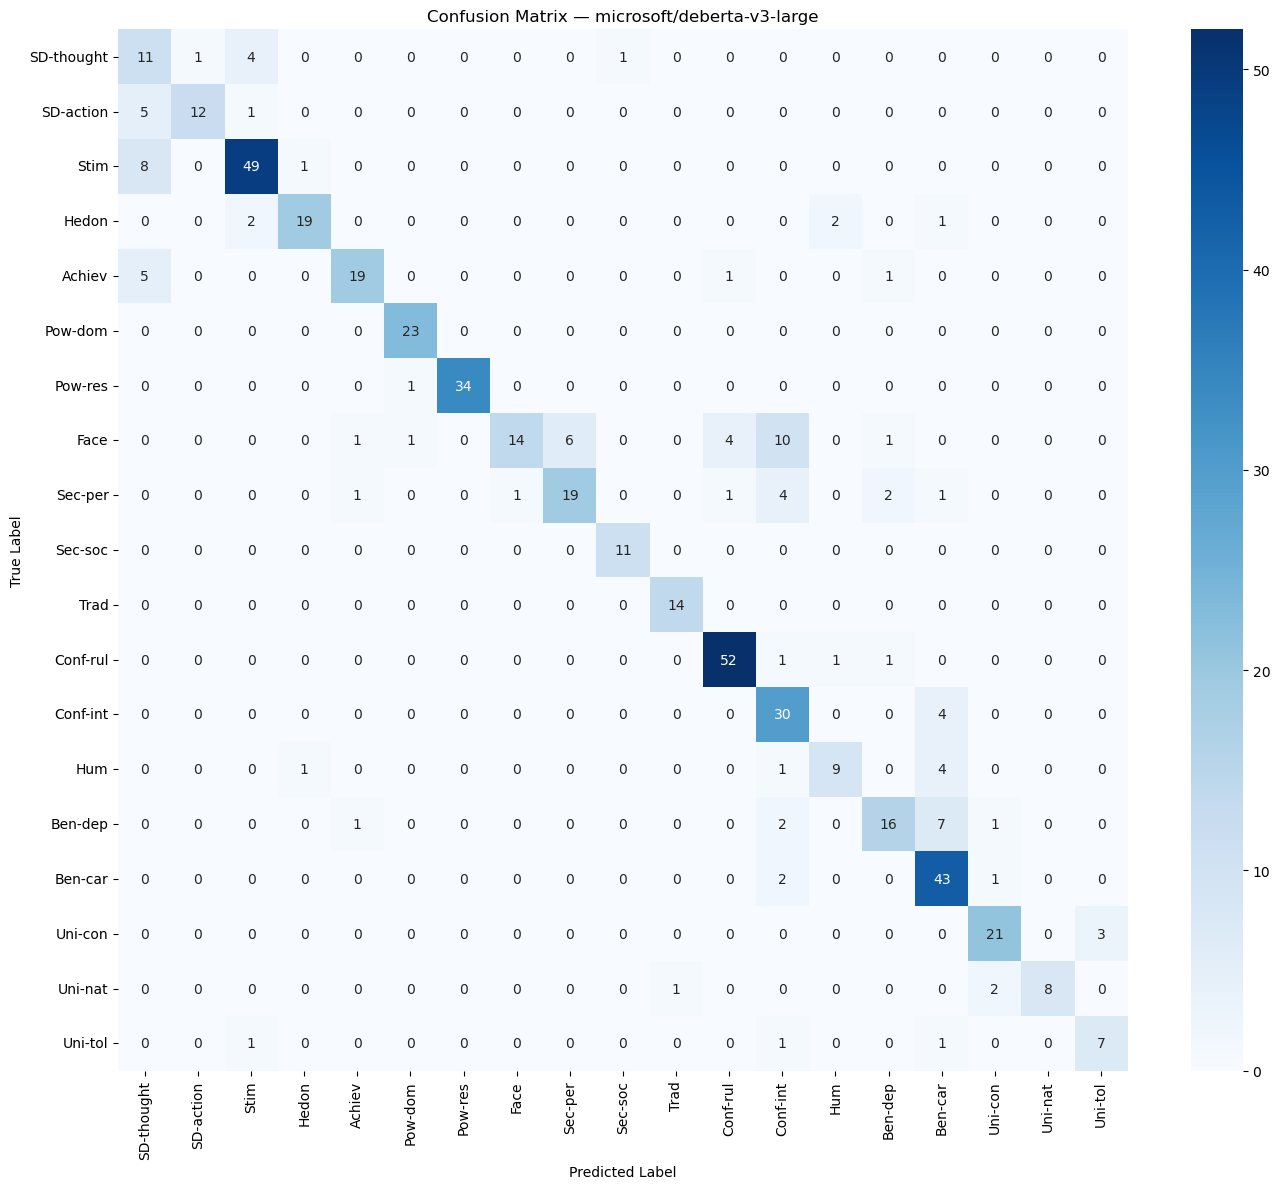

Confusion matrix saved to /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/confusion_matrix.png


In [12]:
# Cell 8: Dev 集综合评估 + 每类 F1 + 混淆矩阵热图
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(dev_dataset)
preds  = np.argmax(pred_output.predictions, axis=-1)
labels = np.array(dev_dataset["label"])

print("=" * 60)
print("Dev Set Evaluation Results")
print("=" * 60)
print(classification_report(
    labels, preds,
    target_names=VALUE_LABELS,
    digits=4
))

# 混淆矩阵热图
cm = confusion_matrix(labels, preds)
short_labels = [
    "SD-thought", "SD-action", "Stim", "Hedon", "Achiev",
    "Pow-dom", "Pow-res", "Face", "Sec-per", "Sec-soc",
    "Trad", "Conf-rul", "Conf-int", "Hum", "Ben-dep",
    "Ben-car", "Uni-con", "Uni-nat", "Uni-tol"
]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=short_labels, yticklabels=short_labels
)
plt.title(f"Confusion Matrix — {MODEL_NAME}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")